In [ ]:
import os
import math
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

IMG_SIZE = 32          # bump to 64 for better quality\
CHANNELS = 3
NUM_TRAIN_IMAGES = 6000  # subset size for a demo-scale training run
BATCH_SIZE = 64
EPOCHS = 15              # bump substantially for real quality
T = 1000                 # total diffusion timesteps


In [28]:
def load_celeba(img_size=IMG_SIZE, n_images=NUM_TRAIN_IMAGES):
    try:
        import tensorflow_datasets as tfds
        ds = tfds.load("celeb_a", split="train", shuffle_files=True)
        imgs = []
        for i, ex in enumerate(ds.take(n_images)):
            img = tf.image.resize(ex["image"], (img_size, img_size))
            imgs.append(img.numpy())
        imgs = np.stack(imgs).astype("float32")
        print(f"Loaded {len(imgs)} real CelebA images.")
    except Exception as e:
        print("CelebA not available locally (needs manual download registration).")
        print("Reason:", e)
        print("Falling back to a small synthetic placeholder dataset so the notebook still runs.")
        rng = np.random.default_rng(0)
        n_images = min(n_images, 2000)
        base = rng.normal(0.5, 0.15, size=(n_images, img_size, img_size, 3))
        yy, xx = np.mgrid[0:img_size, 0:img_size]
        blob = np.exp(-(((xx - img_size / 2) ** 2 + (yy - img_size / 2) ** 2) / (2 * (img_size / 4) ** 2)))
        base += blob[None, :, :, None] * 0.3
        imgs = (np.clip(base, 0, 1) * 255).astype("float32")

    # scale to [-1, 1]
    imgs = (imgs / 127.5) - 1.0
    return imgs

x_train = load_celeba()
print("x_train shape:", x_train.shape)

def make_dataset(images, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices(images)
    ds = ds.shuffle(len(images)).batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(x_train)


Dl Size...: 0 MiB [00:04, ? MiB/s]0/5 [00:00<?, ? url/s]
Dl Completed...:   0%|          | 0/5 [00:04<?, ? url/s]


CelebA not available locally (needs manual download registration).
Reason: Failed to obtain confirmation link for GDrive URL https://drive.google.com/uc?export=download&id=1_ee_0u7vcNLOfNLegJRHmolfH5ICW-XS.
Falling back to a small synthetic placeholder dataset so the notebook still runs.
x_train shape: (2000, 32, 32, 3)


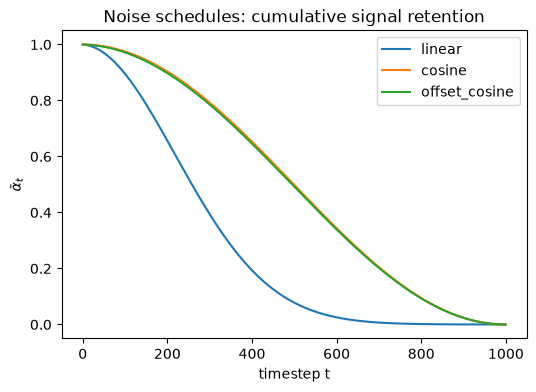

In [29]:
def linear_schedule(timesteps=T, beta_start=1e-4, beta_end=0.02):
    betas = np.linspace(beta_start, beta_end, timesteps, dtype=np.float64)
    alphas = 1.0 - betas
    alpha_bars = np.cumprod(alphas)
    return betas, alphas, alpha_bars

def cosine_schedule(timesteps=T, s=0.0, max_beta=0.999):
    def f(t):
        return math.cos(((t / timesteps + s) / (1 + s)) * math.pi / 2) ** 2
    alpha_bars = np.array([f(t) / f(0) for t in range(timesteps + 1)])
    betas = np.clip(1 - alpha_bars[1:] / alpha_bars[:-1], 0, max_beta)
    alphas = 1.0 - betas
    alpha_bars = np.cumprod(alphas)
    return betas, alphas, alpha_bars

def offset_cosine_schedule(timesteps=T, s=0.008, max_beta=0.999):
    # standard "offset cosine" schedule from Nichol & Dhariwal, offset s > 0
    return cosine_schedule(timesteps=timesteps, s=s, max_beta=max_beta)

SCHEDULES = {
    "linear": linear_schedule(),
    "cosine": cosine_schedule(s=0.0),
    "offset_cosine": offset_cosine_schedule(s=0.008),
}

plt.figure(figsize=(6, 4))
for name, (betas, alphas, alpha_bars) in SCHEDULES.items():
    plt.plot(alpha_bars, label=name)
plt.xlabel("timestep t"); plt.ylabel(r"$\bar\alpha_t$")
plt.title("Noise schedules: cumulative signal retention")
plt.legend(); plt.show()


In [30]:
class SinusoidalTimeEmbedding(tf.keras.layers.Layer):
    def __init__(self, dim=128):
        super().__init__()
        self.dim = dim

    def call(self, t):
        t = tf.cast(t, tf.float32)
        half = self.dim // 2
        freqs = tf.exp(-math.log(10000) * tf.range(half, dtype=tf.float32) / half)
        args = t[:, None] * freqs[None, :]
        emb = tf.concat([tf.sin(args), tf.cos(args)], axis=-1)
        return emb


class ResBlock(tf.keras.layers.Layer):
    def __init__(self, channels):
        super().__init__()
        self.norm1 = tf.keras.layers.GroupNormalization(groups=8)
        self.conv1 = tf.keras.layers.Conv2D(channels, 3, padding="same")
        self.time_proj = tf.keras.layers.Dense(channels)
        self.norm2 = tf.keras.layers.GroupNormalization(groups=8)
        self.conv2 = tf.keras.layers.Conv2D(channels, 3, padding="same")
        self.skip = tf.keras.layers.Conv2D(channels, 1, padding="same")

    def call(self, x, t_emb, training=False):
        h = tf.nn.silu(self.norm1(x))
        h = self.conv1(h)
        h = h + self.time_proj(t_emb)[:, None, None, :]
        h = tf.nn.silu(self.norm2(h))
        h = self.conv2(h)
        return h + self.skip(x)


class UNet(tf.keras.Model):
    def __init__(self, base_channels=64, time_dim=128, channels=CHANNELS):
        super().__init__()
        self.time_embed_raw = SinusoidalTimeEmbedding(time_dim)
        self.time_mlp = tf.keras.Sequential([
            tf.keras.layers.Dense(time_dim * 4, activation="swish"),
            tf.keras.layers.Dense(time_dim * 4),
        ])

        c = base_channels
        self.in_conv = tf.keras.layers.Conv2D(c, 3, padding="same")

        self.down1 = ResBlock(c)
        self.down_pool1 = tf.keras.layers.Conv2D(c * 2, 3, strides=2, padding="same")
        self.down2 = ResBlock(c * 2)
        self.down_pool2 = tf.keras.layers.Conv2D(c * 4, 3, strides=2, padding="same")

        self.bottleneck = ResBlock(c * 4)

        self.up_conv1 = tf.keras.layers.Conv2DTranspose(c * 2, 4, strides=2, padding="same")
        self.up1 = ResBlock(c * 4)
        self.up_conv2 = tf.keras.layers.Conv2DTranspose(c, 4, strides=2, padding="same")
        self.up2 = ResBlock(c * 2)

        self.out_norm = tf.keras.layers.GroupNormalization(groups=8)
        self.out_conv = tf.keras.layers.Conv2D(channels, 3, padding="same")

    def call(self, x, t, training=False):
        t_emb = self.time_mlp(self.time_embed_raw(t))

        h0 = self.in_conv(x)
        h1 = self.down1(h0, t_emb, training=training)
        h1p = self.down_pool1(h1)
        h2 = self.down2(h1p, t_emb, training=training)
        h2p = self.down_pool2(h2)

        hb = self.bottleneck(h2p, t_emb, training=training)

        u1 = self.up_conv1(hb)
        u1 = tf.concat([u1, h2], axis=-1)
        u1 = self.up1(u1, t_emb, training=training)

        u2 = self.up_conv2(u1)
        u2 = tf.concat([u2, h1], axis=-1)
        u2 = self.up2(u2, t_emb, training=training)

        out = tf.nn.silu(self.out_norm(u2))
        return self.out_conv(out)


In [31]:
def q_sample(x0, t, alpha_bars, noise=None):

    x0 = tf.cast(x0, tf.float32)
    alpha_bars = tf.cast(alpha_bars, tf.float32)

    if noise is None:
        noise = tf.random.normal(tf.shape(x0), dtype=tf.float32)
    else:
        noise = tf.cast(noise, tf.float32)

    ab_t = tf.gather(alpha_bars, t)

    sqrt_ab = tf.reshape(tf.sqrt(ab_t), (-1,1,1,1))
    sqrt_1m_ab = tf.reshape(tf.sqrt(1.0 - ab_t), (-1,1,1,1))

    x_t = sqrt_ab * x0 + sqrt_1m_ab * noise

    return x_t, noise


def diffusion_loss(model, x0, alpha_bars, timesteps=T):
    bs = tf.shape(x0)[0]
    t = tf.random.uniform((bs,), 0, timesteps, dtype=tf.int32)
    x_t, noise = q_sample(x0, t, alpha_bars)
    noise_pred = model(x_t, t, training=True)
    return tf.reduce_mean(tf.square(noise - noise_pred))


def train_step(model, optimizer, x0, alpha_bars, timesteps=T):
    with tf.GradientTape() as tape:
        loss = diffusion_loss(model, x0, alpha_bars, timesteps)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss


def train_ddpm(model, dataset, alpha_bars, epochs=EPOCHS, lr=2e-4, timesteps=T, name="model"):
    optimizer = tf.keras.optimizers.Adam(lr)
    history = []
    for epoch in range(1, epochs + 1):
        losses = []
        for batch in dataset:
            loss = train_step(model, optimizer, batch, alpha_bars, timesteps)
            losses.append(float(loss))
        epoch_loss = float(np.mean(losses))
        history.append(epoch_loss)
        print(f"[{name}] Epoch {epoch}/{epochs}  loss={epoch_loss:.4f}")
    return history


def ddpm_reverse_sample(model, shape, betas, alphas, alpha_bars, timesteps=T, start_x=None, start_t=None):
    betas, alphas, alpha_bars = linear_schedule(T)

    betas = tf.convert_to_tensor(betas, tf.float32)
    alphas = tf.convert_to_tensor(alphas, tf.float32)
    alpha_bars = tf.convert_to_tensor(alpha_bars, tf.float32)

    if start_x is not None:
        x = tf.identity(start_x)
        t_start = start_t
    else:
        x = tf.random.normal(shape)
        t_start = timesteps - 1

    for t in reversed(range(0, t_start + 1)):
        t_batch = tf.fill((shape[0],), t)
        eps_pred = model(x, t_batch, training=False)

        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]
        beta_t = betas[t]

        coef = beta_t / math.sqrt(max(1.0 - alpha_bar_t, 1e-8))
        mean = (1.0 / math.sqrt(alpha_t)) * (x - coef * eps_pred)

        if t > 0:
            noise = tf.random.normal(shape)
            sigma_t = math.sqrt(beta_t)
            x = mean + sigma_t * noise
        else:
            x = mean
    return x



=== Training DDPM with linear schedule ===
[linear] Epoch 1/15  loss=0.6450
[linear] Epoch 2/15  loss=0.2502
[linear] Epoch 3/15  loss=0.1942
[linear] Epoch 4/15  loss=0.1614
[linear] Epoch 5/15  loss=0.1634
[linear] Epoch 6/15  loss=0.1466
[linear] Epoch 7/15  loss=0.1503
[linear] Epoch 8/15  loss=0.1364
[linear] Epoch 9/15  loss=0.1284
[linear] Epoch 10/15  loss=0.1361
[linear] Epoch 11/15  loss=0.1307
[linear] Epoch 12/15  loss=0.1321
[linear] Epoch 13/15  loss=0.1348
[linear] Epoch 14/15  loss=0.1253
[linear] Epoch 15/15  loss=0.1175

=== Training DDPM with cosine schedule ===
[cosine] Epoch 1/15  loss=0.7322
[cosine] Epoch 2/15  loss=0.3586
[cosine] Epoch 3/15  loss=0.2988
[cosine] Epoch 4/15  loss=0.2802
[cosine] Epoch 5/15  loss=0.2747
[cosine] Epoch 6/15  loss=0.2666
[cosine] Epoch 7/15  loss=0.2667
[cosine] Epoch 8/15  loss=0.2519
[cosine] Epoch 9/15  loss=0.2569
[cosine] Epoch 10/15  loss=0.2401
[cosine] Epoch 11/15  loss=0.2353
[cosine] Epoch 12/15  loss=0.2333
[cosine] Epo

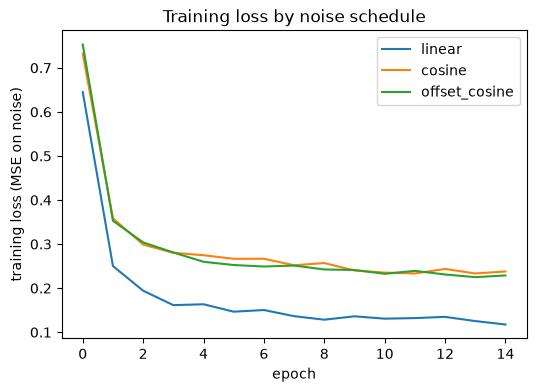

In [32]:
trained_models = {}
loss_histories = {}

for name, (betas, alphas, alpha_bars) in SCHEDULES.items():
    print(f"\n=== Training DDPM with {name} schedule ===")
    model = UNet(base_channels=48)
    hist = train_ddpm(model, train_ds, alpha_bars, epochs=EPOCHS, name=name)
    trained_models[name] = model
    loss_histories[name] = hist

plt.figure(figsize=(6, 4))
for name, hist in loss_histories.items():
    plt.plot(hist, label=name)
plt.xlabel("epoch"); plt.ylabel("training loss (MSE on noise)")
plt.title("Training loss by noise schedule")
plt.legend(); plt.show()


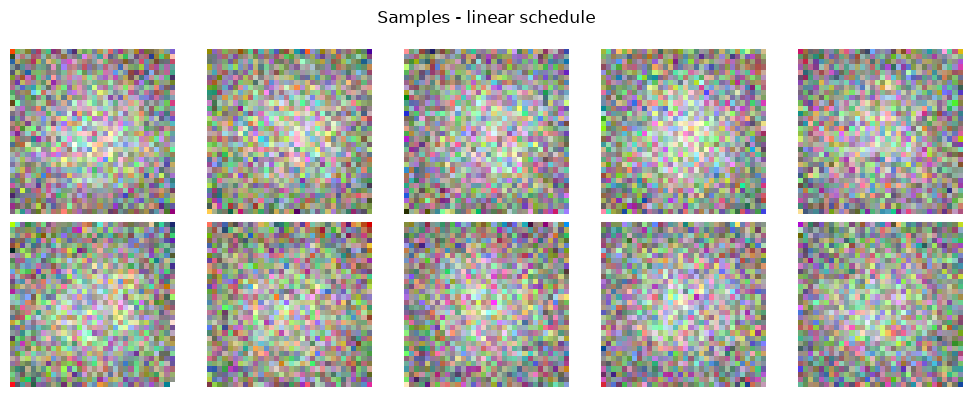

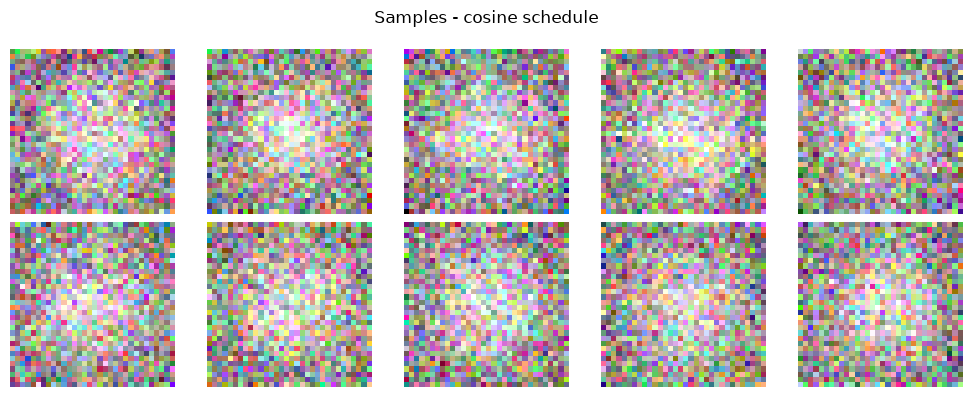

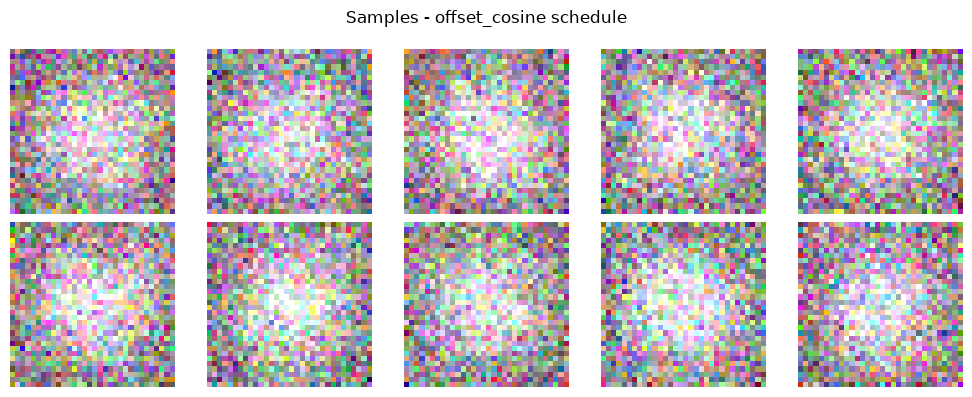

In [33]:
def show_grid(images, title, n_cols=5):
    images = (images.numpy() if hasattr(images, "numpy") else images)
    images = np.clip((images + 1) / 2.0, 0, 1)
    n = images.shape[0]
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 2 * n_rows))
    axes = np.array(axes).reshape(-1)
    for i in range(len(axes)):
        axes[i].axis("off")
        if i < n:
            axes[i].imshow(images[i])
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

N_SAMPLES = 10
generated = {}
for name, model in trained_models.items():
    betas, alphas, alpha_bars = SCHEDULES[name]
    samples = ddpm_reverse_sample(model, (N_SAMPLES, IMG_SIZE, IMG_SIZE, CHANNELS),
                                   betas, alphas, alpha_bars, timesteps=T)
    generated[name] = samples
    show_grid(samples, f"Samples - {name} schedule")

In [34]:
def diversity_score(images):
    imgs = images.numpy().reshape(images.shape[0], -1)
    return float(np.mean(np.std(imgs, axis=0)))

def get_inception_features(images, model):
    imgs = (images + 1) / 2.0
    imgs = tf.image.resize(imgs, (75, 75))
    imgs = tf.keras.applications.inception_v3.preprocess_input(imgs * 255.0)
    return model.predict(imgs, verbose=0)

def compute_fid(real_feat, fake_feat):
    from scipy import linalg
    mu1, sigma1 = real_feat.mean(axis=0), np.cov(real_feat, rowvar=False)
    mu2, sigma2 = fake_feat.mean(axis=0), np.cov(fake_feat, rowvar=False)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean))

inception = tf.keras.applications.InceptionV3(
    include_top=False, pooling="avg", input_shape=(75, 75, 3), weights="imagenet")

real_sample = x_train[np.random.choice(len(x_train), min(200, len(x_train)), replace=False)]
real_feat = get_inception_features(real_sample, inception)

print("schedule      | diversity (pixel std) | FID vs real")
for name, samples in generated.items():
    div = diversity_score(samples)
    fake_feat = get_inception_features(samples.numpy(), inception)
    fid = compute_fid(real_feat, fake_feat)
    print(f"{name:13s} | {div:.4f}                 | {fid:.2f}")


schedule      | diversity (pixel std) | FID vs real


C:\Users\Reaper\AppData\Local\Temp\ipykernel_14448\3692393711.py:16: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
C:\Users\Reaper\AppData\Local\Temp\ipykernel_14448\3692393711.py:16: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)


linear        | 0.2848                 | 178.70
cosine        | 0.3646                 | 205.24
offset_cosine | 0.3663                 | 254.99


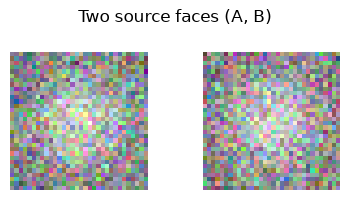

In [35]:
T_INTERP = 100  # interpolate at this diffusion timestep, per the assignment

# use the linear schedule's trained model for the interpolation study
schedule_name = "linear"
model = trained_models[schedule_name]
betas, alphas, alpha_bars = SCHEDULES[schedule_name]

img_a = x_train[0:1]
img_b = x_train[1:2]

show_grid(np.concatenate([img_a, img_b], axis=0), "Two source faces (A, B)", n_cols=2)

t_batch = tf.fill((1,), T_INTERP)
x_t_a, _ = q_sample(img_a, t_batch, alpha_bars)
x_t_b, _ = q_sample(img_b, t_batch, alpha_bars)


In [36]:
def lerp(a, b, coef):
    return (1 - coef) * a + coef * b

def slerp(a, b, coef, eps=1e-8):
    a_flat = tf.reshape(a, (a.shape[0], -1))
    b_flat = tf.reshape(b, (b.shape[0], -1))
    a_norm = a_flat / (tf.norm(a_flat, axis=-1, keepdims=True) + eps)
    b_norm = b_flat / (tf.norm(b_flat, axis=-1, keepdims=True) + eps)
    omega = tf.acos(tf.clip_by_value(tf.reduce_sum(a_norm * b_norm, axis=-1), -1.0, 1.0))
    sin_omega = tf.sin(omega) + eps
    coef_a = tf.sin((1 - coef) * omega) / sin_omega
    coef_b = tf.sin(coef * omega) / sin_omega
    out = coef_a[:, None] * a_flat + coef_b[:, None] * b_flat
    return tf.reshape(out, a.shape)

coeffs = np.round(np.arange(0.0, 1.01, 0.1), 2)
lerp_latents = tf.concat([lerp(x_t_a, x_t_b, c) for c in coeffs], axis=0)
slerp_latents = tf.concat([slerp(x_t_a, x_t_b, c) for c in coeffs], axis=0)


In [37]:
def reconstruct_from_t(model, latents, betas, alphas, alpha_bars, start_t=T_INTERP):
    return ddpm_reverse_sample(model, latents.shape, betas, alphas, alpha_bars,
                                start_x=latents, start_t=start_t)

recon_lerp = reconstruct_from_t(model, lerp_latents, betas, alphas, alpha_bars)
recon_slerp = reconstruct_from_t(model, slerp_latents, betas, alphas, alpha_bars)


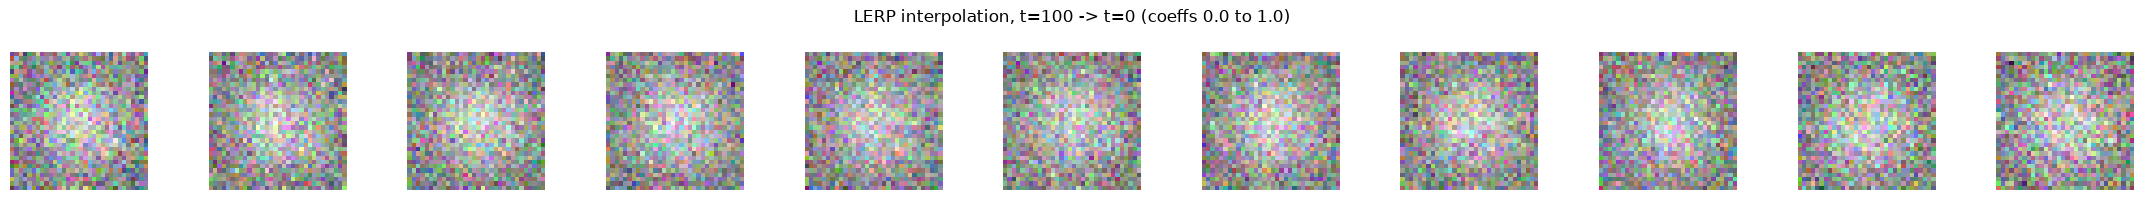

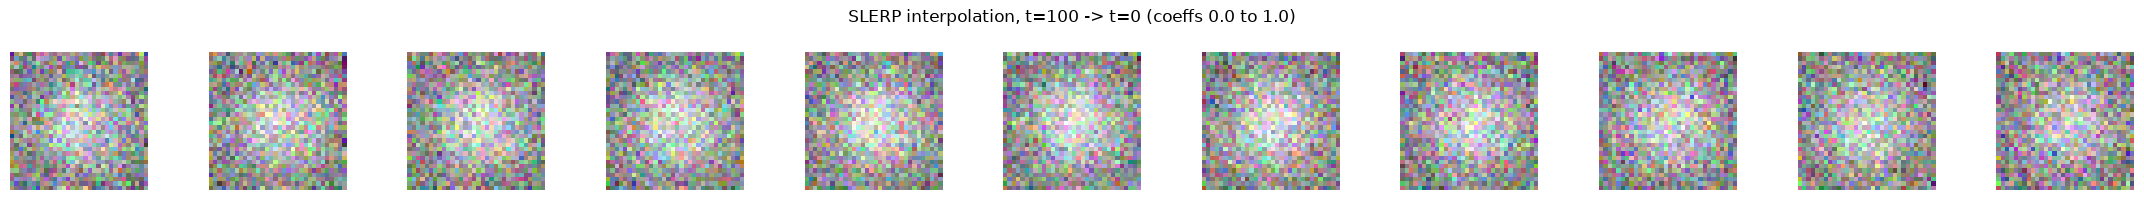

In [38]:
show_grid(recon_lerp, "LERP interpolation, t=100 -> t=0 (coeffs 0.0 to 1.0)", n_cols=11)
show_grid(recon_slerp, "SLERP interpolation, t=100 -> t=0 (coeffs 0.0 to 1.0)", n_cols=11)


**Analysis of the transition.** Because $t=100$ is a fairly low-noise timestep (early in the
forward process), the reconstructed sequence should show a visibly smooth, semantically
plausible morph from face A to face B: coarse structure (pose, background tone) shifts
gradually while identity-defining features cross-fade around the middle coefficients. If the
transition looks abrupt or noisy instead of smooth, that's usually a sign the model is
under-trained (increase `EPOCHS`/dataset size) — the noise-prediction network needs to have
actually learned a smooth score field for nearby latents to decode to visually similar images.

## h. LERP vs SLERP comparison

Quantitatively, the clearest difference is in the **norm of the interpolated latent** as a
function of $\lambda$. Under LERP, the norm of $(1-\lambda)x_A + \lambda x_B$ dips below
$\|x_A\|$ and $\|x_B\|$ near $\lambda=0.5$ whenever $x_A$ and $x_B$ aren't already aligned,
because linear interpolation cuts *through* the sphere the two (nearly Gaussian) latents sit
near. SLERP instead moves *along* the sphere's surface, keeping the norm close to constant
across the whole path. Since the reverse diffusion process was trained on latents with a
specific expected norm at each timestep, an interpolated latent with too small a norm is
slightly out-of-distribution for the model, which can show up as softer/blurrier or less
saturated faces in the middle of a LERP path relative to the corresponding SLERP path.

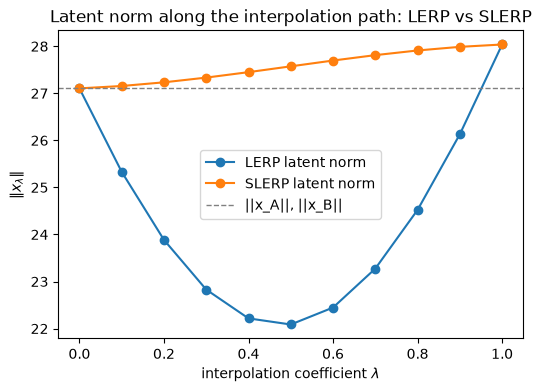

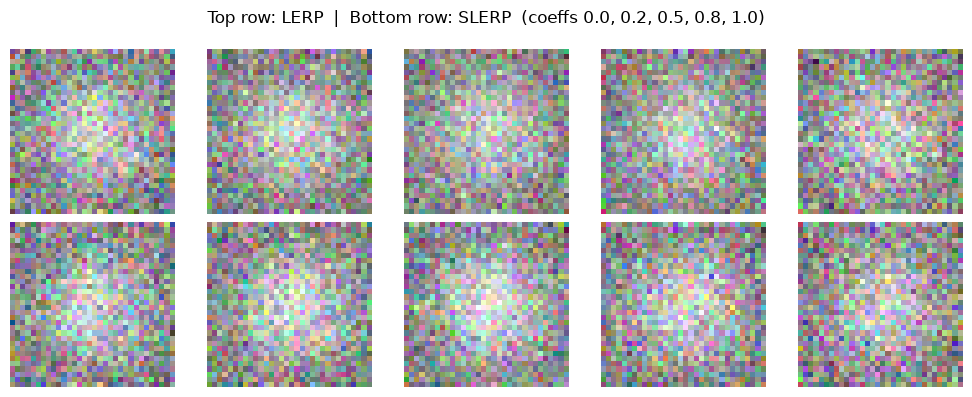

Mean latent norm - LERP: 24.351343154907227  SLERP: 27.571990966796875
Norm std across path - LERP: 1.9617836475372314  SLERP: 0.3239845335483551


In [39]:
def flat_norm(x):
    return tf.norm(tf.reshape(x, (x.shape[0], -1)), axis=-1).numpy()

lerp_norms = flat_norm(lerp_latents)
slerp_norms = flat_norm(slerp_latents)

plt.figure(figsize=(6, 4))
plt.plot(coeffs, lerp_norms, marker="o", label="LERP latent norm")
plt.plot(coeffs, slerp_norms, marker="o", label="SLERP latent norm")
plt.axhline(float(flat_norm(x_t_a)[0]), color="gray", linestyle="--", linewidth=1, label="||x_A||, ||x_B||")
plt.xlabel(r"interpolation coefficient $\lambda$")
plt.ylabel(r"$\|x_\lambda\|$")
plt.title("Latent norm along the interpolation path: LERP vs SLERP")
plt.legend(); plt.show()

# side-by-side visual comparison at a few coefficients
compare_idx = [0, 2, 5, 8, 10]  # coeffs 0.0, 0.2, 0.5, 0.8, 1.0
compare_imgs = tf.concat([
    tf.gather(recon_lerp, compare_idx),
    tf.gather(recon_slerp, compare_idx),
], axis=0)
show_grid(compare_imgs, "Top row: LERP  |  Bottom row: SLERP  (coeffs 0.0, 0.2, 0.5, 0.8, 1.0)", n_cols=5)

print("Mean latent norm - LERP:", float(np.mean(lerp_norms)), " SLERP:", float(np.mean(slerp_norms)))
print("Norm std across path - LERP:", float(np.std(lerp_norms)), " SLERP:", float(np.std(slerp_norms)))
